### Выбор датасета и метрик 

**Датасет:** Blood Cells Images — изображения клеток крови для классификации на 4 типа: EOSINOPHIL, LYMPHOCYTE, MONOCYTE, NEUTROPHIL. 

Датасет Blood Cell Images выбран для решения задачи автоматизации: нейросети справляются с анализом мазков быстрее человека и не допускают случайных пропусков. Это позволяет ускорить диагностику и дать медикам возможность сосредоточиться на лечении, а не на подсчете клеток в микроскопе.

**Метрики:**
- **Accuracy** — общая доля правильных ответов
- **Balanced Accuracy** — средняя точность по классам, важна при дисбалансе
- **Macro-F1** — среднее F1 по всем классам, чувствительна к миноритарным классам, объединяет Precision и Recall

Также для более детального анализа можно использовать **Confusion Matrix** для оценки ошибок классификации между классами и **Classification Report** для получения Precision, Recall и F1-score по каждому классу.

### Анализ датасета

Импортируем неибходимые библиотеки

In [2]:
from common import *

Подсчёт количества изображений в каждом классе

In [ ]:
CLASS_NAMES = sorted(d.name for d in TRAIN_DIR.iterdir() if d.is_dir()) # сортировка классов

def count_images(base_dir, class_names): 
    """ Подсчёт количества изображений в каждом классе """ 
    counts = {} # словарь для хранения количества изображений в каждом классе   
    for cls in class_names:
        cls_dir = base_dir / cls # путь к директории класса
        counts[cls] = len(list(cls_dir.glob("*.jpeg"))) # подсчёт количества изображений в классе
    return counts

train_counts = count_images(TRAIN_DIR, CLASS_NAMES) # подсчёт количества изображений в каждом классе для тренировочного набора
test_counts = count_images(TEST_DIR, CLASS_NAMES) # подсчёт количества изображений в каждом классе для тестового набора

print("\nTRAIN")
for cls, cnt in train_counts.items():
    print(f" {cls}: {cnt}")

print(f" Итого: {sum(train_counts.values())}")

print("\nTEST")
for cls, cnt in test_counts.items():
    print(f" {cls}: {cnt}")

print(f" Итого: {sum(test_counts.values())}")


TRAIN
 EOSINOPHIL: 2497
 LYMPHOCYTE: 2483
 MONOCYTE: 2478
 NEUTROPHIL: 2499
 Итого: 9957

TEST
 EOSINOPHIL: 623
 LYMPHOCYTE: 620
 MONOCYTE: 620
 NEUTROPHIL: 624
 Итого: 2487


Визуализация распределения классов

/tmp/ipykernel_16390/2183324943.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), ax=axes[0], palette="Set2")
/tmp/ipykernel_16390/2183324943.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), ax=axes[1], palette="Set2")


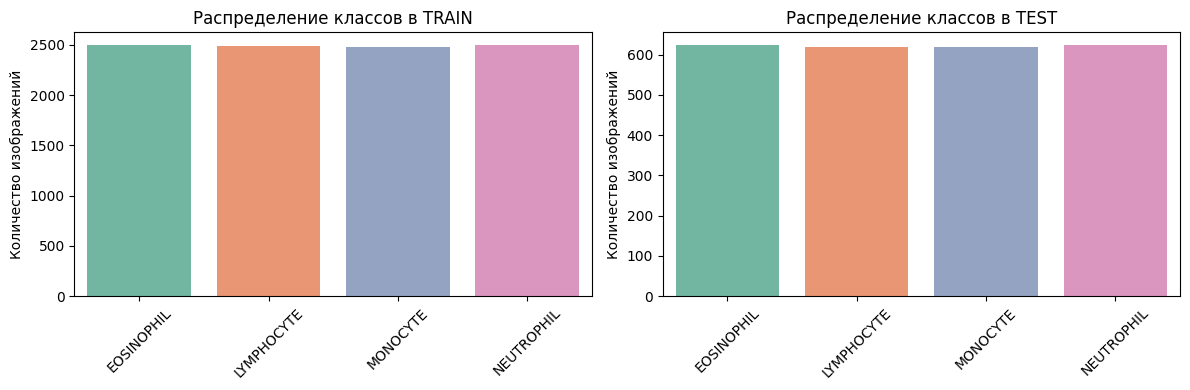

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), ax=axes[0], palette="Set2")
axes[0].set_title("Распределение классов в TRAIN")
axes[0].set_ylabel("Количество изображений")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), ax=axes[1], palette="Set2")
axes[1].set_title("Распределение классов в TEST")
axes[1].set_ylabel("Количество изображений")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Примеры изображений

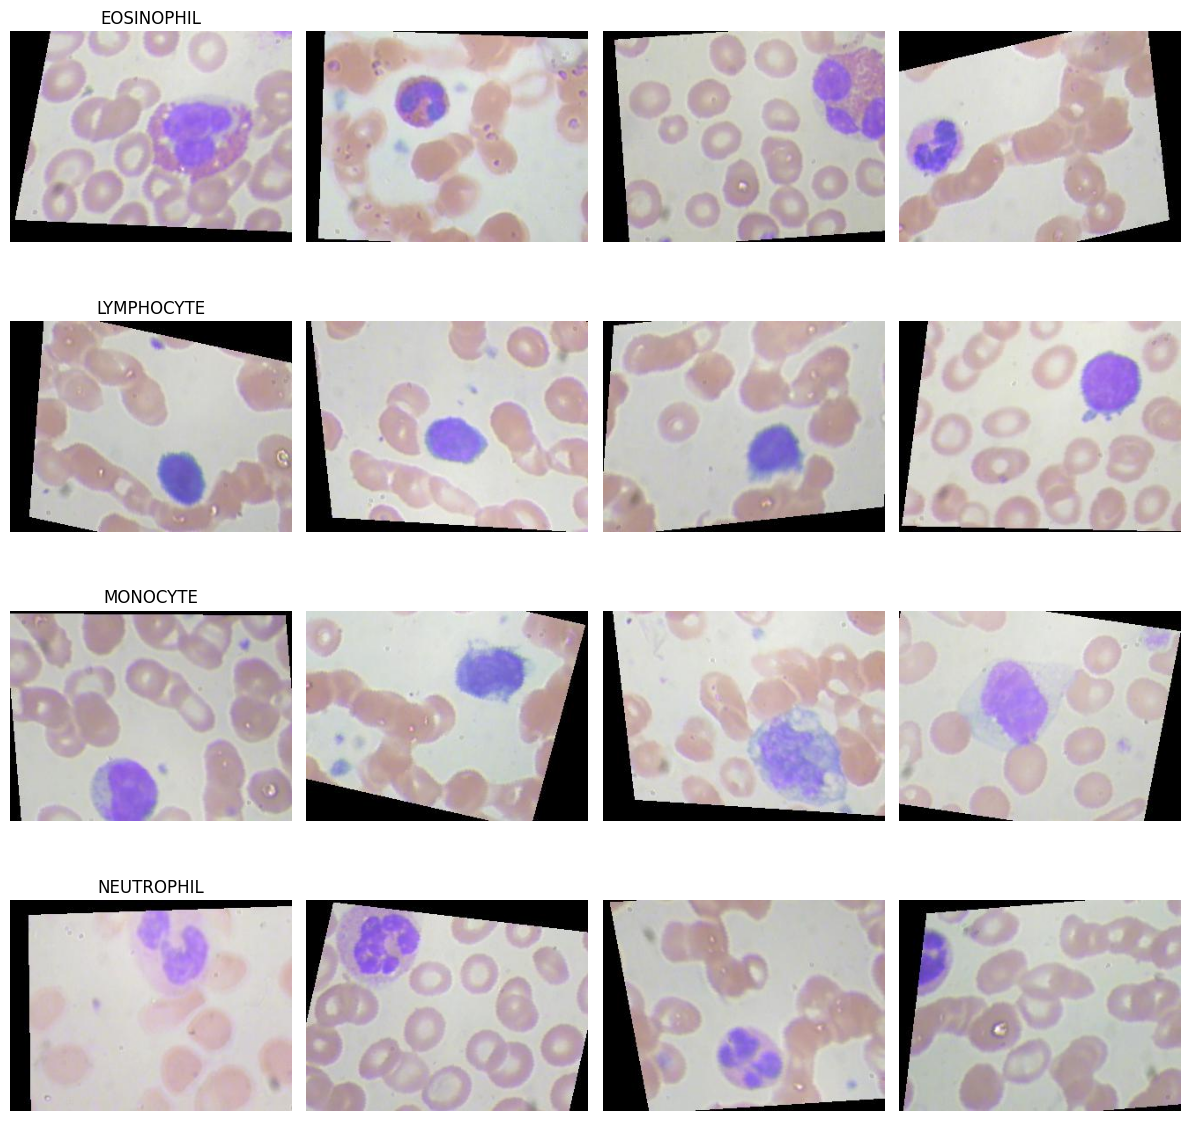

In [5]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, cls in enumerate(CLASS_NAMES):
    cls_dir = TRAIN_DIR / cls
    files = list(cls_dir.glob("*.jpeg"))[:4]
    for j, f in enumerate(files):
        img = Image.open(f)
        axes[i, j].imshow(img)
        axes[i, j].set_title(cls if j == 0 else "")
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

Размеры изображений в датасете

In [ ]:
def get_images_sizes(base_dir, class_names, max_per_class=5):
    """ Получение размеров изображений в датасете """  
    sizes = [] # список для хранения размеров изображений
    for cls in class_names:
        cls_dir = base_dir / cls # путь к директории класса
        files = list(cls_dir.glob("*.jpeg"))[:max_per_class]
        for f in files:
            img = Image.open(f)
            sizes.append({"class": cls, "width": img.size[0], "height": img.size[1], "mode": img.mode})
    return pd.DataFrame(sizes)


train_sizes = get_images_sizes(TRAIN_DIR, CLASS_NAMES) # получение размеров изображений в датасете для тренировочного набора
print("Размеры изображений в TRAIN, первые 5 на класс")
display(train_sizes.head(20))

print(f"Уникальные размеры в TRAIN: {train_sizes[['width', 'height']].drop_duplicates().values.tolist()}")
print(f"Режимы изображений в TRAIN: {train_sizes['mode'].unique()}")

Размеры изображений в TRAIN, первые 5 на класс


,class,width,height,mode
0,EOSINOPHIL,320,240,RGB
1,EOSINOPHIL,320,240,RGB
2,EOSINOPHIL,320,240,RGB
3,EOSINOPHIL,320,240,RGB
4,EOSINOPHIL,320,240,RGB
5,LYMPHOCYTE,320,240,RGB
6,LYMPHOCYTE,320,240,RGB
7,LYMPHOCYTE,320,240,RGB
8,LYMPHOCYTE,320,240,RGB
9,LYMPHOCYTE,320,240,RGB


Уникальные размеры в TRAIN: [[320, 240]]
Режимы изображений в TRAIN: ['RGB']


Создание и сохранение сплитов

In [ ]:
full_train_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание датасета для тренировочного набора
test_dataset = BloodCellsDataset(TEST_DIR, transform=val_test_transform) # создание датасета для тестового набора

targets = [label for _, label in full_train_dataset] # получение целевых меток для тренировочного набора
train_indices, val_indices = train_test_split(
    np.arange(len(full_train_dataset)), # индексы изображений
    test_size=VAL_SPLIT, # размер валидационного набора
    stratify=targets, # стратификация по целевым меткам
    random_state=SEED # фиксированное значение для воспроизводимости
)

train_dataset = BloodCellsDataset(TRAIN_DIR, transform=train_transform) # создание датасета для тренировочного набора
val_dataset = BloodCellsDataset(TRAIN_DIR, transform=val_test_transform) # создание датасета для валидационного набора

train_dataset.samples = [train_dataset.samples[i] for i in train_indices] # получение изображений для тренировочного набора
val_dataset.samples = [val_dataset.samples[i] for i in val_indices] # получение изображений для валидационного набора

print(f"TRAIN: {len(train_dataset)}")
print(f"VAL: {len(val_dataset)}")
print(f"TEST: {len(test_dataset)}")

def print_class_dist(dataset, name):
    """ Вывод распределения классов в датасете """
    labels = [label for _, label in dataset.samples] # получение целевых меток для датасета
    counts = np.bincount(labels) # подсчёт количества изображений в каждом классе
    dist = {dataset.class_names[i]: int(counts[i]) for i in range(len(counts))} # создание словаря с распределением классов
    print(f"{name}: {dist}")

print_class_dist(train_dataset, "TRAIN")
print_class_dist(val_dataset, "VAL")
print_class_dist(test_dataset, "TEST")

os.makedirs("outputs", exist_ok=True)

# Сохранение информации о сплитах
splits_info = {
    "train_indices": train_indices.tolist(), # индексы изображений для тренировочного набора
    "val_indices": val_indices.tolist(), # индексы изображений для валидационного набора
    "train_size": len(train_dataset), # количество изображений для тренировочного набора
    "val_size": len(val_dataset), # количество изображений для валидационного набора
    "test_size": len(test_dataset), # количество изображений для тестового набора
    "class_names": CLASS_NAMES,
    "batch_size": BATCH_SIZE,
    "img_size": IMG_SIZE,
    "seed": SEED
}

with open("outputs/splits_info.json", "w") as f:
    json.dump(splits_info, f)

print("Сплиты сохранены в outputs/splits_info.json")

TRAIN: 7965
VAL: 1992
TEST: 2487
TRAIN: {'EOSINOPHIL': 1998, 'LYMPHOCYTE': 1986, 'MONOCYTE': 1982, 'NEUTROPHIL': 1999}
VAL: {'EOSINOPHIL': 499, 'LYMPHOCYTE': 497, 'MONOCYTE': 496, 'NEUTROPHIL': 500}
TEST: {'EOSINOPHIL': 623, 'LYMPHOCYTE': 620, 'MONOCYTE': 620, 'NEUTROPHIL': 624}
Сплиты сохранены в outputs/splits_info.json
